# 실습문제 7 프로젝트 과제 ----------------------------------------------------------------
현재 Grocery 데이터 대신 다른 데이터를 사용하여 연관분석을 수행하시오.

### 후보 데이터
* Online Retail Dataset (UCI)
* Instacart Market Basket Dataset
* Kaggle Grocery Dataset
* E-Commerce Transaction Dataset

## 수행 내용
1. 데이터 수집
2. 거래 데이터 전처리
3. One-Hot Encoding
4. Support 계산
5. Confidence 계산
6. Lift 계산
7. 규칙 생성
8. 추천 상품 도출
9. 시각화
10. 결과 보고서 작성

## 최종 프로젝트 보고서 문항
1. 사용한 데이터셋 설명
2. 전체 거래 수
3. 전체 상품 수
4. 가장 많이 판매된 상품
5. 생성된 규칙 수
6. 최고 Support 규칙
7. 최고 Confidence 규칙
8. 최고 Lift 규칙
9. 추천 시스템 결과
10. 비즈니스 활용 방안

In [1]:
import os
import urllib.request
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# ============================================================
# 1. 데이터 수집 (UCI Online Retail Dataset)
# ============================================================
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

xlsx_path = os.path.join(DATA_DIR, "OnlineRetail.xlsx")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

if not os.path.exists(xlsx_path):
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(url, xlsx_path)
print("데이터 준비 완료")

데이터 준비 완료


In [3]:
# ============================================================
# 2. 데이터 로드
# ============================================================
df = pd.read_excel(xlsx_path, engine="openpyxl")
print(f"원본 데이터 Shape: {df.shape}")
display(df.head())

원본 데이터 Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# ============================================================
# 3. 거래 데이터 전처리
# ============================================================
df = df.dropna(subset=["InvoiceNo", "StockCode", "Description"])
df = df[df["Quantity"] > 0]
df["Description"] = df["Description"].str.strip()

# 영문/숫자 오인 방지 및 고유 거래 묶기
transactions = (
    df.groupby("InvoiceNo")["Description"]
    .apply(lambda x: list(set(x)))
    .tolist()
)
# 아이템이 2개 이상인 거래만 선택
transactions = [t for t in transactions if len(t) >= 2]
num_transactions = len(transactions)
print(f"유효 거래 수: {num_transactions}")

유효 거래 수: 18338


In [5]:
# ============================================================
# 4. One-Hot Encoding (PyTorch 텐서 변환)
# ============================================================
all_items = sorted(list(set(item for t in transactions for item in t)))
num_items = len(all_items)
print(f"전체 고유 상품 수: {num_items}")

item_to_idx = {item: idx for idx, item in enumerate(all_items)}
idx_to_item = {idx: item for item, idx in item_to_idx.items()}

X = torch.zeros((num_transactions, num_items), dtype=torch.float32, device=device)

for row_idx, transaction in enumerate(transactions):
    col_indices = [item_to_idx[item] for item in transaction]
    X[row_idx, col_indices] = 1.0

print(f"One-Hot Matrix Shape: {X.shape}")

전체 고유 상품 수: 4005
One-Hot Matrix Shape: torch.Size([18338, 4005])


In [6]:
# ============================================================
# 5. Support 계산
# ============================================================
item_support_tensor = X.mean(dim=0)
item_support = item_support_tensor.cpu().numpy()

item_freq_df = pd.DataFrame({
    "item": all_items,
    "support": item_support,
    "count": (item_support_tensor * num_transactions).to(torch.int64).cpu().numpy()
}).sort_values("support", ascending=False)

print("\n--- 상위 20개 인기 상품 ---")
display(item_freq_df.head(20))

# Support 계산 함수 (기존 prod 대용으로 텐서 논리곱 연산 활용 가능)
def calculate_itemset_support(X_matrix, item_indices):
    # 모든 선택된 컬럼이 1인 행을 찾음
    selected = X_matrix[:, list(item_indices)]
    both = torch.all(selected == 1.0, dim=1)
    return both.to(torch.float32).mean().item()


--- 상위 20개 인기 상품 ---


,item,support,count
3823,WHITE HANGING HEART T-LIGHT HOLDER,0.122205,2241
1800,JUMBO BAG RED RETROSPOT,0.113317,2078
2833,REGENCY CAKESTAND 3 TIER,0.107264,1967
2395,PARTY BUNTING,0.091122,1671
1987,LUNCH BAG RED RETROSPOT,0.085233,1563
216,ASSORTED COLOUR BIRD ORNAMENT,0.079234,1453
3111,SET OF 3 CAKE TINS PANTRY DESIGN,0.075035,1376
2321,PACK OF 72 RETROSPOT CAKE CASES,0.071982,1320
1979,LUNCH BAG BLACK SKULL.,0.069310,1271
2180,NATURAL SLATE HEART CHALKBOARD,0.068055,1248


In [7]:
# ============================================================
# 6. Frequent Itemset 탐색 (기존 코드에서 Apriori 원리(가지치기) 적용)
# ============================================================
MIN_SUPPORT = 0.01
MIN_CONFIDENCE = 0.30
MAX_LEN = 3

# 1단계: 크기 1인 빈발 항목 집합
frequent_single_items = [
    item_to_idx[row.item]
    for row in item_freq_df.itertuples(index=False)
    if row.support >= MIN_SUPPORT
]

# 결과를 담을 딕셔너리
frequent_itemsets = {
    (idx,): item_support_tensor[idx].item() for idx in frequent_single_items
}

# 각 크기(k)별로 "살아남은 조합"만 저장할 딕셔너리
current_frequent_sets = {(idx,): item_support_tensor[idx].item() for idx in frequent_single_items}

for k in range(2, MAX_LEN + 1):
    # 이전 단계(k-1)에서 살아남은 아이템들의 고유 집합만 추출 (가지치기의 핵심)
    allowed_items = set(idx for itemset in current_frequent_sets.keys() for idx in itemset)
    
    # allowed_items로만 조합 생성 -> 조합 수가 기하급수적으로 줄어듭니다.
    candidate_combinations = list(combinations(allowed_items, k))
    
    # 3단계의 경우 추가 가지치기: 조합의 모든 (k-1) 하위 집합이 이전 단계에서 빈발했는지 확인
    if k > 2:
        valid_candidates = []
        for candidate in candidate_combinations:
            # 예: (A, B, C)의 하위 조합인 (A,B), (B,C), (A,C)가 모두 이전 단계에 있었는지 확인
            subsets = combinations(candidate, k - 1)
            if all(sub in current_frequent_sets for sub in subsets):
                valid_candidates.append(candidate)
        candidate_combinations = valid_candidates

    # 이번 턴에 살아남은 것들을 기록할 임시 딕셔너리
    next_frequent_sets = {}
    count_k = 0
    
    print(f"{k}개 크기 후보군 개수: {len(candidate_combinations)}개 검사 중...")
    
    for itemset in candidate_combinations:
        support = calculate_itemset_support(X, itemset)
        if support >= MIN_SUPPORT:
            frequent_itemsets[itemset] = support
            next_frequent_sets[itemset] = support
            count_k += 1
            
    print(f"-> {k}개 크기 최종 빈발 Itemset 개수: {count_k}")
    
    # 다음 턴(k+1)을 위해 현재 살아남은 집합 업데이트
    current_frequent_sets = next_frequent_sets
    
    # 만약 더 이상 살아남은 조합이 없다면 조기 종료
    if not current_frequent_sets:
        break

print(f"\n[완료] 총 빈발 Itemset 개수: {len(frequent_itemsets)}")

2개 크기 후보군 개수: 392941개 검사 중...
-> 2개 크기 최종 빈발 Itemset 개수: 1122
3개 크기 후보군 개수: 2270개 검사 중...
-> 3개 크기 최종 빈발 Itemset 개수: 238

[완료] 총 빈발 Itemset 개수: 2247


In [8]:
# ============================================================
# 7. Confidence / Lift 계산 및 규칙 생성
# ============================================================
def generate_rules(frequent_itemsets, min_confidence=0.3):
    rules = []
    for itemset, support in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
            
        for lhs_len in range(1, len(itemset)):
            for lhs in combinations(itemset, lhs_len):
                lhs = tuple(sorted(lhs))
                rhs = tuple(sorted(set(itemset) - set(lhs)))
                
                lhs_support = frequent_itemsets.get(lhs)
                rhs_support = frequent_itemsets.get(rhs)
                
                if lhs_support is None or rhs_support is None:
                    continue
                    
                confidence = support / lhs_support
                if confidence < min_confidence:
                    continue
                    
                lift = confidence / rhs_support
                
                rules.append({
                    "lhs": tuple(idx_to_item[i] for i in lhs),
                    "rhs": tuple(idx_to_item[i] for i in rhs),
                    "support": support,
                    "confidence": confidence,
                    "lift": lift
                })
    return pd.DataFrame(rules)

rules_df = generate_rules(frequent_itemsets, MIN_CONFIDENCE)

if not rules_df.empty:
    rules_df["rule"] = rules_df.apply(lambda r: f"{r['lhs']} -> {r['rhs']}", axis=1)
    print(f"생성된 연관 규칙 수: {len(rules_df)}")
    display(rules_df.sort_values("lift", ascending=False).head(10))
else:
    print("조건을 만족하는 연관 규칙이 없습니다.")

생성된 연관 규칙 수: 1678


,lhs,rhs,support,confidence,lift,rule
1053,"(HERB MARKER THYME,)","(HERB MARKER PARSLEY, HERB MARKER ROSEMARY)",0.011070,0.860170,73.366458,"('HERB MARKER THYME',) -> ('HERB MARKER PARSLE..."
1054,"(HERB MARKER PARSLEY, HERB MARKER ROSEMARY)","(HERB MARKER THYME,)",0.011070,0.944186,73.366458,"('HERB MARKER PARSLEY', 'HERB MARKER ROSEMARY'..."
1052,"(HERB MARKER ROSEMARY,)","(HERB MARKER PARSLEY, HERB MARKER THYME)",0.011070,0.845833,72.821087,"('HERB MARKER ROSEMARY',) -> ('HERB MARKER PAR..."
1055,"(HERB MARKER PARSLEY, HERB MARKER THYME)","(HERB MARKER ROSEMARY,)",0.011070,0.953052,72.821087,"('HERB MARKER PARSLEY', 'HERB MARKER THYME') -..."
641,"(HERB MARKER THYME,)","(HERB MARKER ROSEMARY,)",0.012051,0.936441,71.551872,"('HERB MARKER THYME',) -> ('HERB MARKER ROSEMA..."
640,"(HERB MARKER ROSEMARY,)","(HERB MARKER THYME,)",0.012051,0.920833,71.551872,"('HERB MARKER ROSEMARY',) -> ('HERB MARKER THY..."
639,"(HERB MARKER CHIVES,)","(HERB MARKER PARSLEY,)",0.010525,0.923445,71.151825,"('HERB MARKER CHIVES',) -> ('HERB MARKER PARSL..."
638,"(HERB MARKER PARSLEY,)","(HERB MARKER CHIVES,)",0.010525,0.810924,71.151825,"('HERB MARKER PARSLEY',) -> ('HERB MARKER CHIV..."
1056,"(HERB MARKER ROSEMARY, HERB MARKER THYME)","(HERB MARKER PARSLEY,)",0.011070,0.918552,70.774820,"('HERB MARKER ROSEMARY', 'HERB MARKER THYME') ..."
1051,"(HERB MARKER PARSLEY,)","(HERB MARKER ROSEMARY, HERB MARKER THYME)",0.011070,0.852941,70.774820,"('HERB MARKER PARSLEY',) -> ('HERB MARKER ROSE..."


In [9]:
# ============================================================
# 8. 추천 시스템 함수
# ============================================================
def recommend(product, top_n=5):
    if rules_df.empty:
        return pd.DataFrame()
    
    result = rules_df[rules_df["lhs"].apply(lambda x: product in x)]
    result = result.sort_values(["lift", "confidence"], ascending=False)
    return result.head(top_n)

top_item = item_freq_df.iloc[0]["item"]
recommendations = recommend(top_item)

print(f"\n--- [{top_item}] 구매 고객 추천 결과 ---")
if not recommendations.empty:
    display(recommendations[["rule", "support", "confidence", "lift"]])
else:
    print("추천할 만한 연관 규칙이 발견되지 않았습니다.")


--- [WHITE HANGING HEART T-LIGHT HOLDER] 구매 고객 추천 결과 ---


,rule,support,confidence,lift
1204,"('WHITE HANGING HEART T-LIGHT HOLDER', 'WOODEN...",0.011888,0.643068,10.740053
1028,"('HEART OF WICKER SMALL', 'WHITE HANGING HEART...",0.011124,0.521739,10.354602
1205,"('WHITE HANGING HEART T-LIGHT HOLDER', 'WOODEN...",0.011888,0.534314,10.111707
1027,"('HEART OF WICKER LARGE', 'WHITE HANGING HEART...",0.011124,0.569832,8.729814
953,"('DOTCOM POSTAGE', 'WHITE HANGING HEART T-LIGH...",0.010852,0.731618,6.456403


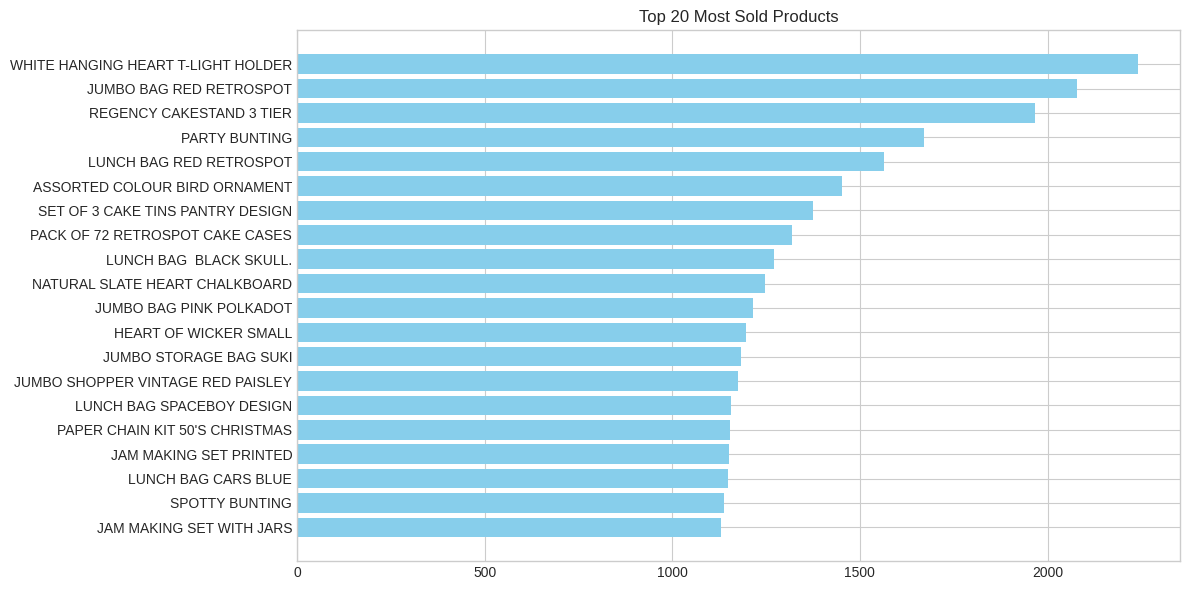

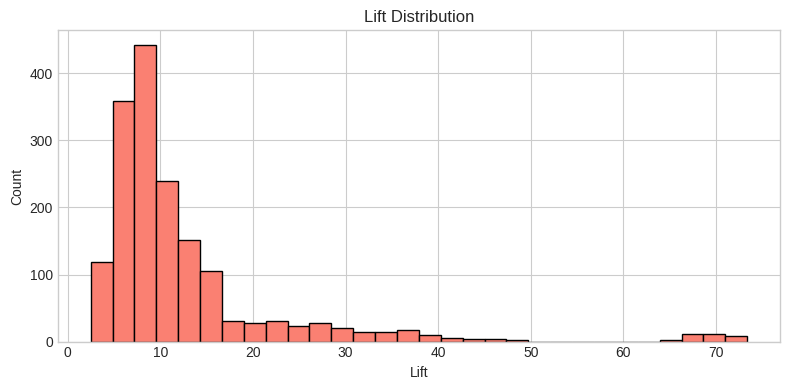

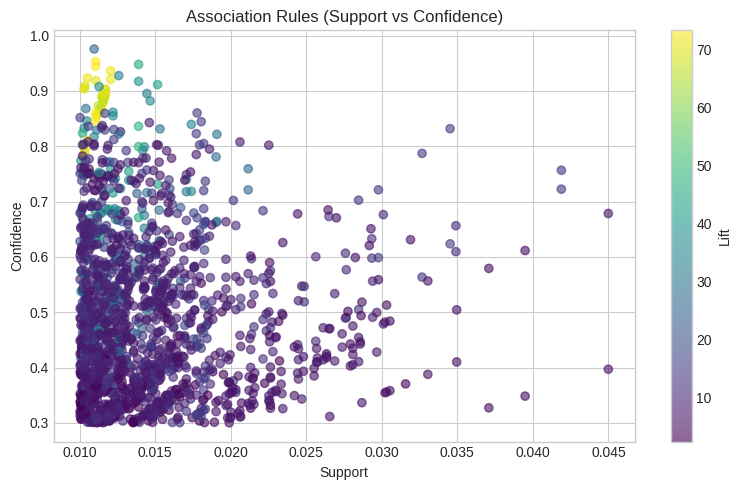

In [10]:
# ============================================================
# 9. 시각화
# ============================================================
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. 판매 상위 20개 상품
plt.figure(figsize=(12, 6))
top20 = item_freq_df.head(20)
plt.barh(top20["item"], top20["count"], color='skyblue')
plt.title("Top 20 Most Sold Products")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

if not rules_df.empty:
    # 2. Lift 분포
    plt.figure(figsize=(8, 4))
    plt.hist(rules_df["lift"], bins=30, color='salmon', edgecolor='black')
    plt.title("Lift Distribution")
    plt.xlabel("Lift")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # 3. Support vs Confidence
    plt.figure(figsize=(8, 5))
    plt.scatter(rules_df["support"], rules_df["confidence"], c=rules_df["lift"], cmap='viridis', alpha=0.6)
    plt.colorbar(label='Lift')
    plt.xlabel("Support")
    plt.ylabel("Confidence")
    plt.title("Association Rules (Support vs Confidence)")
    plt.tight_layout()
    plt.show()

In [14]:
# ============================================================
# 10. 결과 보고서 작성
# ============================================================
print("=" * 60)
print("최종 프로젝트 보고서")
print("=" * 60)
print("1. 사용한 데이터셋       : UCI Online Retail Dataset")
print("- 전자상거래(온라인 쇼핑몰)의 실제 판매 거래 데이터를 담고 있는 대표적인 장바구니 분석(Market Basket Analysis) 데이터셋")
print(f"2. 전체 유효 거래 수     : {num_transactions}")
print(f"3. 전체 고유 상품 수     : {num_items}")
print(f"4. 가장 많이 판매된 상품  : {item_freq_df.iloc[0]['item']}")
print(f"5. 생성된 규칙 수         : {len(rules_df)}")

if not rules_df.empty:
    best_support = rules_df.sort_values("support", ascending=False).iloc[0]
    best_confidence = rules_df.sort_values("confidence", ascending=False).iloc[0]
    best_lift = rules_df.sort_values("lift", ascending=False).iloc[0]

    print(f"\n6. 최고 Support 규칙    : {best_support['rule']} ({best_support['support']:.4f})")
    print(f"7. 최고 Confidence 규칙 : {best_confidence['rule']} ({best_confidence['confidence']:.4f})")
    print(f"8. 최고 Lift 규칙       : {best_lift['rule']} ({best_lift['lift']:.4f})")
else:
    print("\n[안내] 최소 조건을 만족하는 규칙이 없어 6~8번 항목을 출력할 수 없습니다.")

print("\n9. 추천 시스템 예시 결과 (최고 인기 상품 기준)")
if not recommendations.empty:
    display(recommendations[["rule", "support", "confidence", "lift"]])
else:
    print("추천 데이터 없음")

print("\n10. 비즈니스 활용 방안")
print("""
- 장바구니 추천 시스템 도입 및 결제 전 팝업 노출
- 교차판매(Cross Selling)를 위한 오프라인 연관 상품 근접 진열
- 연관 강도가 높은 상품 묶음 패키지(Bundle) 상품 기획 및 할인 구성
- 특정 상품 구매 고객 대상 타겟팅 쿠폰 발행 및 개인화 이메일 마케팅
""")

최종 프로젝트 보고서
1. 사용한 데이터셋       : UCI Online Retail Dataset
- 전자상거래(온라인 쇼핑몰)의 실제 판매 거래 데이터를 담고 있는 대표적인 장바구니 분석(Market Basket Analysis) 데이터셋
2. 전체 유효 거래 수     : 18338
3. 전체 고유 상품 수     : 4005
4. 가장 많이 판매된 상품  : WHITE HANGING HEART T-LIGHT HOLDER
5. 생성된 규칙 수         : 1678

6. 최고 Support 규칙    : ('JUMBO BAG RED RETROSPOT',) -> ('JUMBO BAG PINK POLKADOT',) (0.0450)
7. 최고 Confidence 규칙 : ('BEADED CRYSTAL HEART PINK ON STICK',) -> ('DOTCOM POSTAGE',) (0.9757)
8. 최고 Lift 규칙       : ('HERB MARKER THYME',) -> ('HERB MARKER PARSLEY', 'HERB MARKER ROSEMARY') (73.3665)

9. 추천 시스템 예시 결과 (최고 인기 상품 기준)


,rule,support,confidence,lift
1204,"('WHITE HANGING HEART T-LIGHT HOLDER', 'WOODEN...",0.011888,0.643068,10.740053
1028,"('HEART OF WICKER SMALL', 'WHITE HANGING HEART...",0.011124,0.521739,10.354602
1205,"('WHITE HANGING HEART T-LIGHT HOLDER', 'WOODEN...",0.011888,0.534314,10.111707
1027,"('HEART OF WICKER LARGE', 'WHITE HANGING HEART...",0.011124,0.569832,8.729814
953,"('DOTCOM POSTAGE', 'WHITE HANGING HEART T-LIGH...",0.010852,0.731618,6.456403



10. 비즈니스 활용 방안

- 장바구니 추천 시스템 도입 및 결제 전 팝업 노출
- 교차판매(Cross Selling)를 위한 오프라인 연관 상품 근접 진열
- 연관 강도가 높은 상품 묶음 패키지(Bundle) 상품 기획 및 할인 구성
- 특정 상품 구매 고객 대상 타겟팅 쿠폰 발행 및 개인화 이메일 마케팅

